In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

60000
60000
10000
10000


In [6]:
# Normalize the pixel values to the range [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
# Reshape the data to fit the model
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [9]:
# model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

In [10]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
# Train the model
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 31ms/step - accuracy: 0.9496 - loss: 0.1622 - val_accuracy: 0.9883 - val_loss: 0.0392
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9829 - loss: 0.0569 - val_accuracy: 0.9871 - val_loss: 0.0365
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9872 - loss: 0.0410 - val_accuracy: 0.9891 - val_loss: 0.0324
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.9900 - loss: 0.0320 - val_accuracy: 0.9910 - val_loss: 0.0275
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9919 - loss: 0.0261 - val_accuracy: 0.9916 - val_loss: 0.0253
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9927 - loss: 0.0223 - val_accuracy: 0.9915 - val_loss: 0.0257
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9943 - loss: 0.0178 - val_accuracy: 0.9927 - val_loss: 0.0246
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9952 -

In [12]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9924 - loss: 0.0302
Test accuracy: 0.9924


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9978 - loss: 0.0064 - val_accuracy: 0.9983 - val_loss: 0.0062
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 52ms/step - accuracy: 0.9983 - loss: 0.0048 - val_accuracy: 0.9987 - val_loss: 0.0062
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 52ms/step - accuracy: 0.9983 - loss: 0.0049 - val_accuracy: 0.9990 - val_loss: 0.0052
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9981 - loss: 0.0056 - val_accuracy: 0.9988 - val_loss: 0.0064
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9988 - loss: 0.0035 - val_accuracy: 0.9977 - val_loss: 0.0086
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 52ms/step - accuracy: 0.9982 - loss: 0.0048 - val_accuracy: 0.9990 - val_loss: 0.0065
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9983 - loss: 0.0056 - val_accuracy: 0.9985 - val_loss: 0.0080
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.9990 - loss: 0.0031 - 

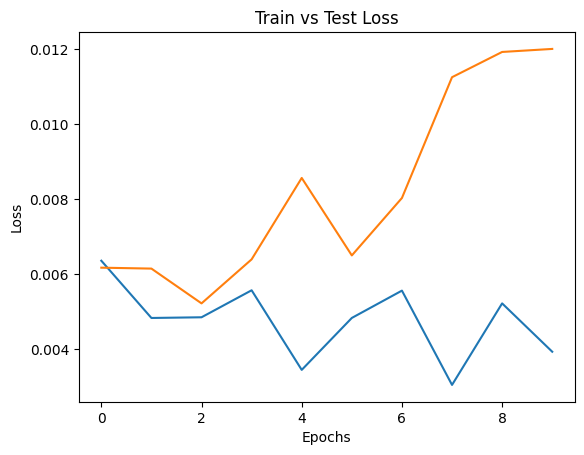

In [14]:
# train vs test loss
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Test Loss')
plt.show()

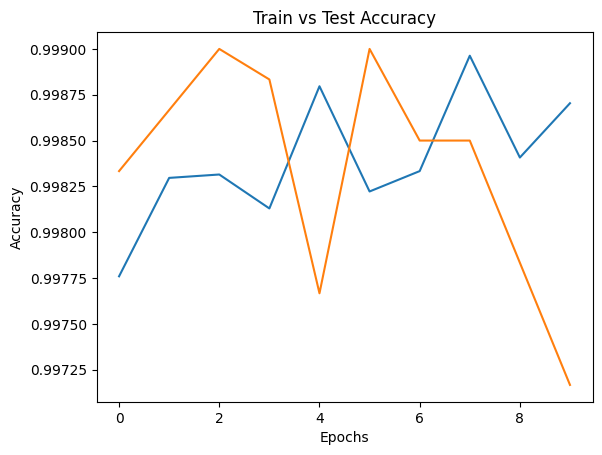

In [15]:
# train accuracy vs test accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')
plt.show()